# Fig 5e — CFP versus FOXF1 pixel density in 10% BMPR1A knockdown morphs

**Feeds:** **Fig 5e**, drawn by the second-to-last cell; the last cell writes the tables in `derived/`.

Ported from the original analysis notebook `Mutant CFP-YFP-correlation.ipynb`. That notebook is
exploratory, with 43 code cells. Seven of them are on the path to the figure it saved
(`densityheatmap_FOXF1-CFP.pdf`, `.png` and `.svg`), and this notebook keeps those seven in their
original order: code cells 1 to 4, 10, 12 and 13.

**Changes from the original notebook**
1. Removed the cells the figure does not use, and the notebook's three markdown headings:
   code cells 5 to 9 (reloading the first stack, a thresholded view of one plane, a histogram of the
   pooled CFP values, and a count of the pixels above either gate); code cell 11, which is empty;
   code cell 14 (an interactive datashader scatter); code cell 15 (quadrant proportions and an
   under-representation test with the gates at the medians); code cells 16 to 19 (an opponent score
   from the histogram, which raised a `NameError`, and a Spearman correlation that has no saved
   result); and code cells 20 to 43 (an earlier version of the heatmap without contours or gates,
   scatter plots, histograms and thresholds for single stacks, and empty cells; none of them ran in
   the saved session).
2. The cell that lists the image folders (third code cell) reads them from `data/mutant analysis/`
   in this lane's directory, or from the directory named by the environment variable
   `FIG5E_IMAGE_ROOT`, instead of `mutant analysis/` in the working directory. Lines added at the top
   of that cell find the lane directory, check that the image directory exists and set the output
   directory. The folder names and file patterns are unchanged.
3. The figure cell (second-to-last) saves the three files in this lane's `output/` directory instead
   of the working directory. Nothing else in it changed.
4. Added the last code cell, which writes the values the panel is drawn from to `output/derived/`:
   the pixel counts in the panel's 256 × 256 bins, the bin edges, and a summary holding n, the pixel
   count, the DAPI cutoff, the gates and the quadrant pixel counts. It reads what the cells above
   computed and changes none of it. It is not part of the original analysis, so it has no saved
   output here. This lane's `derived/` directory holds the tables from a run of this notebook on the
   images, and `scripts/render_fig5e_panel.py` redraws the panel from them.
5. Outputs are those of the original notebook's saved session, the one that saved the figure.
   Execution counts are cleared.

The loading cell adds a small random dither to the CFP and FOXF1 values, drawn from NumPy's global
random number generator without a seed, as in the original. A re-run therefore gives slightly
different histogram and quadrant counts from the saved session.


In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
import scipy
from cmcrameri.cm import batlow
from matplotlib import cm, colors

In [ ]:
flat_dapi_merged = np.array([])
flat_cfp_merged = np.array([])
flat_yfp_merged = np.array([])

In [ ]:
from pathlib import Path
import os

LANE = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "imaging" / "cfp_foxf1_density_fig5e" / "README.md").is_file()) / "imaging" / "cfp_foxf1_density_fig5e"
IMAGE_ROOT = Path(os.environ.get("FIG5E_IMAGE_ROOT", LANE / "data" / "mutant analysis"))
if not IMAGE_ROOT.is_dir():
    raise FileNotFoundError(f"Image folders not found in {IMAGE_ROOT}. See imaging/cfp_foxf1_density_fig5e/README.md.")
OUT = LANE / "output"
OUT.mkdir(parents=True, exist_ok=True)

DAPI_file_list = [f"{IMAGE_ROOT}/0303-1-DAPI-2/*.tif", f"{IMAGE_ROOT}/0303-2-DAPI/*.tif", f"{IMAGE_ROOT}/0315-DAPI/*.tif"]
CFP_file_list = [f"{IMAGE_ROOT}/0303-1-CFP-2/*.tif", f"{IMAGE_ROOT}/0303-2-CFP/*.tif", f"{IMAGE_ROOT}/0315-CFP/*.tif"]
YFP_file_list = [f"{IMAGE_ROOT}/0303-1-YFP-2/*.tif", f"{IMAGE_ROOT}/0303-2-YFP/*.tif", f"{IMAGE_ROOT}/0315-YFP/*.tif"]

/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_16144/1010556319.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stack_dapi= np.array([imageio.imread(f) for f in DAPI_list])
/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_16144/1010556319.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stack_cfp = np.array([imageio.imread(f) for f in CFP_list])


(111, 1024, 1024)
(111, 1024, 1024)


/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_16144/1010556319.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  stack_yfp = np.array([imageio.imread(f) for f in YFP_list])


(111, 1024, 1024)


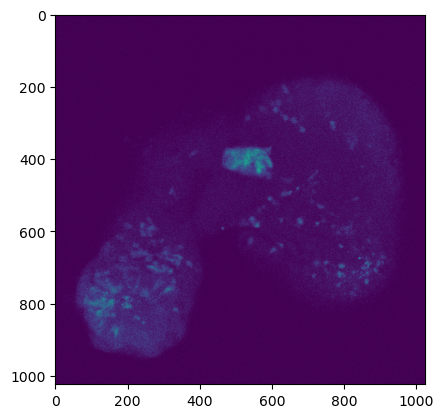

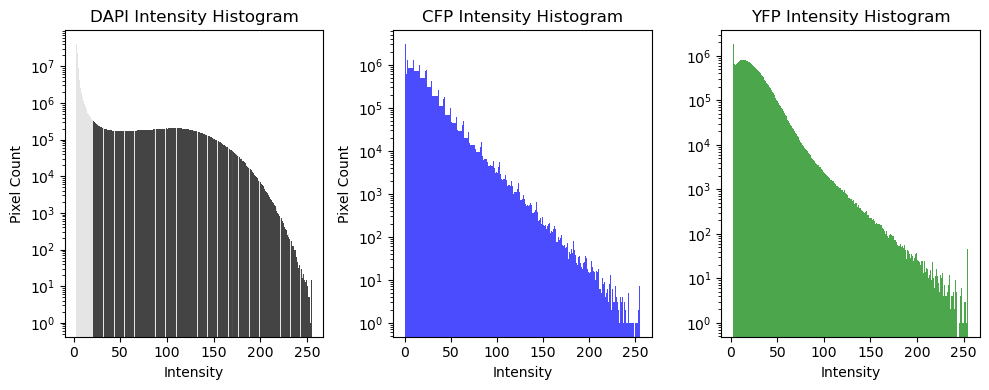

(99, 1024, 1024)
(99, 1024, 1024)
(99, 1024, 1024)


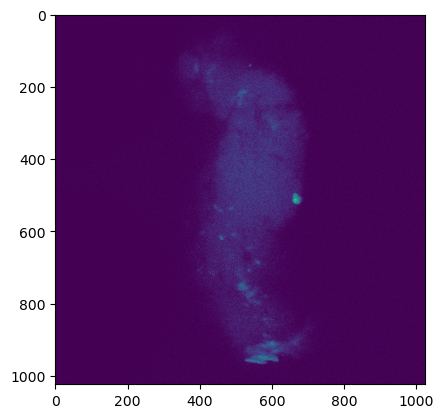

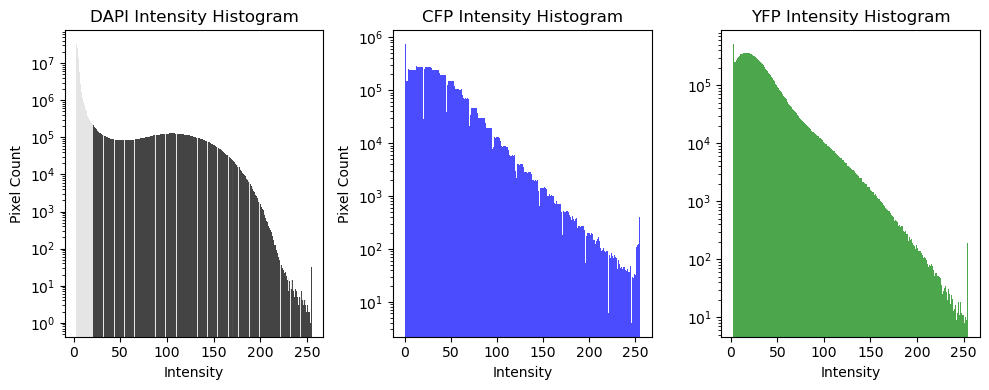

(107, 1024, 1024)
(107, 1024, 1024)
(107, 1024, 1024)


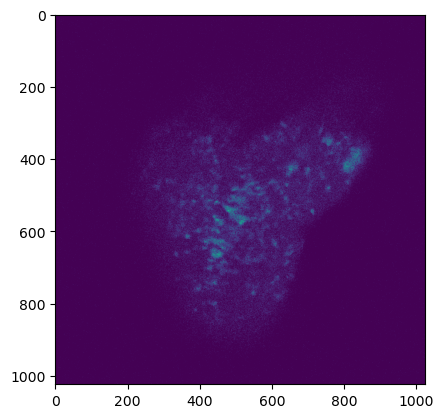

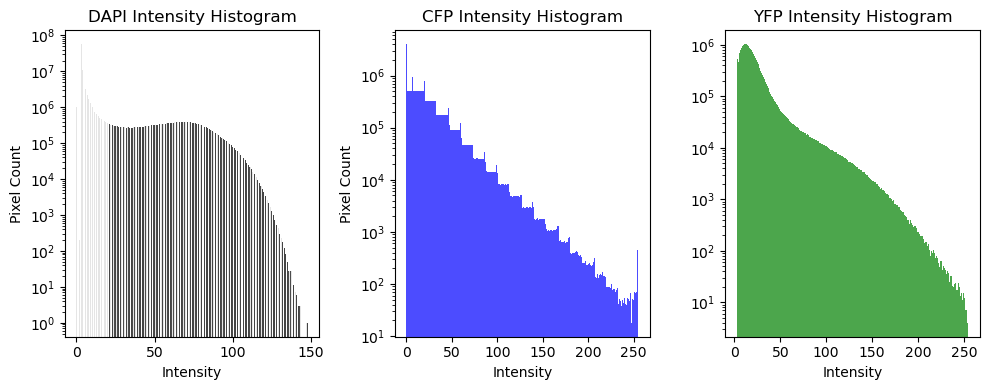

In [ ]:
for i in range (3):
    DAPI_list = sorted(glob.glob(DAPI_file_list[i]))
    stack_dapi= np.array([imageio.imread(f) for f in DAPI_list])
    print(stack_dapi.shape)  # (Z, Y, X)
    
    CFP_list = sorted(glob.glob(CFP_file_list[i]))
    stack_cfp = np.array([imageio.imread(f) for f in CFP_list])
    print(stack_cfp.shape)  # (Z, Y, X)
    
    YFP_list = sorted(glob.glob(YFP_file_list[i]))
    stack_yfp = np.array([imageio.imread(f) for f in YFP_list])
    print(stack_yfp.shape)  # (Z, Y, X)
    
    plt.imshow(stack_dapi[28])
    
    stack_dapi[28]>50
    
    plt.imshow(stack_dapi[28])
    
    dapi_cutoff = 20
    plt.imshow(stack_dapi[28]>dapi_cutoff)
    
    plt.imshow(stack_yfp[28])
    
    plt.imshow(stack_cfp[28])
    
    # How much was data quantized
    
    flat_dapi = stack_dapi.flatten()
    unique_dapi = np.unique(flat_dapi)
    diffs_dapi = np.diff(unique_dapi)
    spacing_dapi = np.mean(diffs_dapi)
    
    flat_cfp = stack_cfp.flatten()
    unique_cfp = np.unique(flat_cfp)
    diffs_cfp = np.diff(unique_cfp)
    spacing_cfp = np.mean(diffs_cfp)
    
    flat_yfp = stack_yfp.flatten()
    unique_yfp = np.unique(flat_yfp)
    diffs_yfp = np.diff(unique_yfp)
    spacing_yfp = np.mean(diffs_yfp)
    
    dapi_cutoff = 20
    
    # Flatten one or both channels
    flat_dapi = stack_dapi.flatten()
    flat_cfp = stack_cfp.flatten()
    flat_yfp = stack_yfp.flatten()
    
    # Add jitter to counteract quantization from Leica software
    jitter_cfp = 1.2*spacing_cfp/2  # Tweak based on how spread you want
    flat_cfp = np.clip(flat_cfp + np.random.uniform(-jitter_cfp, jitter_cfp, size=flat_cfp.shape), 0, 255)
    jitter_yfp = spacing_yfp/2  # Tweak based on how spread you want
    flat_yfp = np.clip(flat_yfp + np.random.uniform(-jitter_yfp, jitter_yfp, size=flat_yfp.shape), 0, 255)
    
    # Plot histograms
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(flat_dapi, bins=255,color='black', alpha=0.1, log=True)
    plt.hist(flat_dapi[flat_dapi>dapi_cutoff], bins=255,color='black', alpha=0.7, log=True)
    plt.title("DAPI Intensity Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Pixel Count")
    
    plt.subplot(1, 3, 2)
    plt.hist(flat_cfp[flat_dapi>dapi_cutoff], bins=256,color='blue', alpha=0.7, log=True)
    plt.title("CFP Intensity Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Pixel Count")
    #plt.ylim(0,10000)
    
    plt.subplot(1, 3, 3)
    plt.hist(flat_yfp[flat_dapi>dapi_cutoff], bins=255,color='green', alpha=0.7, log=True)
    plt.title("YFP Intensity Histogram")
    plt.xlabel("Intensity")
    #plt.ylim(0,10000)
    
    plt.tight_layout()
    plt.show()

    flat_dapi_merged = np.concatenate([flat_dapi_merged, flat_dapi[flat_dapi>dapi_cutoff]])
    flat_cfp_merged = np.concatenate([flat_cfp_merged, flat_cfp[flat_dapi>dapi_cutoff]])
    flat_yfp_merged = np.concatenate([flat_yfp_merged, flat_yfp[flat_dapi>dapi_cutoff]])

In [ ]:
def annotate_quadrants(ax, x_thresh, y_thresh, props, text_kwargs=None, line_kwargs=None):
    """
    Draw quadrant lines and annotate each quadrant with its percentage.
    
    Parameters
    ----------
    ax : matplotlib Axes
        Axes object to draw on.
    x_thresh, y_thresh : float
        Threshold values for vertical and horizontal lines.
    props : dict
        Quadrant proportions in [0,1] with keys Qll, Qlr, Qul, Qur
        (lower-left, lower-right, upper-left, upper-right).
    text_kwargs : dict
        Extra keyword args for text() (fontsize, color, weight, etc.)
    line_kwargs : dict
        Extra keyword args for ax.axvline/ax.axhline (color, lw, etc.)
    """
    if text_kwargs is None:
        text_kwargs = dict(fontsize=10, color='black', weight='bold')
    if line_kwargs is None:
        line_kwargs = dict(color='gray', lw=1.0, ls='--')
    
    # Draw the quadrant lines
    ax.axvline(x_thresh, **line_kwargs)
    ax.axhline(y_thresh, **line_kwargs)
    
    # Get current axis limits for label placement
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Label positions (fractional offset from edges)
    dx = 0.05 * (xmax - xmin)
    dy = 0.05 * (ymax - ymin)
    
    # Annotate each quadrant with % (format to 1 decimal place)
    ax.text(x_thresh - dx, y_thresh - dy, f"{props['Qll']*100:.1f}%", 
            ha='right', va='top', **text_kwargs)
    ax.text(x_thresh + dx, y_thresh - dy, f"{props['Qlr']*100:.1f}%", 
            ha='left', va='top', **text_kwargs)
    ax.text(x_thresh - dx, y_thresh + dy, f"{props['Qul']*100:.1f}%", 
            ha='right', va='bottom', **text_kwargs)
    ax.text(x_thresh + dx, y_thresh + dy, f"{props['Qur']*100:.1f}%", 
            ha='left', va='bottom', **text_kwargs)

In [ ]:
from scipy.stats import binomtest

def compute_quadrant_stats(x, y, x_thresh=None, y_thresh=None, *, use_medians=True, weights=None):
    """
    Returns:
      - counts: dict with Qll, Qlr, Qul, Qur (ll=lower-left, lr=lower-right, ul=upper-left, ur=upper-right)
      - props: same keys, values in [0,1]
      - ur_void_z: (obs_UR - exp_UR) / sqrt(N * p * (1-p))  under independence
      - ur_p_less: exact binomial p-value (alternative='less') for UR underrepresentation
      - thresholds: dict with x_thresh, y_thresh actually used
      - indep_exp_UR: expected UR proportion under independence (px_pos * py_pos)
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    # drop NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    N = x.size
    if N == 0:
        raise ValueError("No finite data after NaN filtering.")

    # thresholds
    if use_medians or (x_thresh is None or y_thresh is None):
        xm = np.median(x)
        ym = np.median(y)
    else:
        xm = float(x_thresh)
        ym = float(y_thresh)

    # weights (optional)
    if weights is None:
        w = np.ones(N, float)
    else:
        w = np.asarray(weights, float)[mask]
        if w.size != N:
            raise ValueError("weights must match x/y length")
        if np.any(w < 0):
            raise ValueError("weights must be nonnegative")

    # quadrant masks (>= for "positive" gate, as in FACS)
    x_pos = x >= xm
    y_pos = y >= ym

    Qll = np.sum(w[~x_pos & ~y_pos])  # lower-left
    Qlr = np.sum(w[ x_pos & ~y_pos])  # lower-right
    Qul = np.sum(w[~x_pos &  y_pos])  # upper-left
    Qur = np.sum(w[ x_pos &  y_pos])  # upper-right

    W = Qll + Qlr + Qul + Qur  # total weight (== N if unweighted)

    counts = dict(Qll=Qll, Qlr=Qlr, Qul=Qul, Qur=Qur)
    props  = {k: v / W for k, v in counts.items()}

    # independence expectation based on marginal positives
    px_pos = np.sum(w[x_pos]) / W
    py_pos = np.sum(w[y_pos]) / W
    p_indep = px_pos * py_pos

    # UR "void" statistics (use unweighted N for exact binomial)
    # Map weights to counts if you actually have integer weights; otherwise fall back to approx
    k_ur = int(Qur) if np.allclose(Qur, round(Qur)) else int(np.round(Qur))
    n_eff = int(W) if np.allclose(W, round(W)) else int(np.round(W))

    # exact binomial p-value for underrepresentation (one-sided)
    ur_p_less = binomtest(k_ur, n_eff, p_indep, alternative='less').pvalue

    # z-score (normal approx; always computed for a quick effect size)
    var = n_eff * p_indep * (1 - p_indep)
    ur_void_z = (Qur - W * p_indep) / np.sqrt(var + 1e-12)

    return dict(
        counts=counts,
        props=props,
        ur_void_z=float(ur_void_z),
        ur_p_less=float(ur_p_less),
        thresholds=dict(x_thresh=xm, y_thresh=ym),
        indep_exp_UR=float(p_indep)
    )

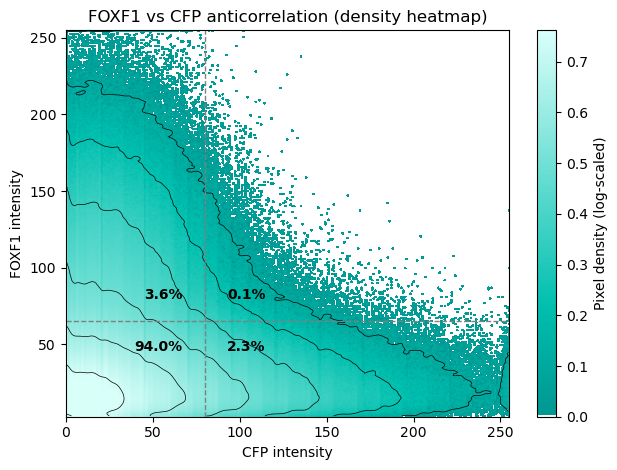

In [ ]:
with plt.rc_context({"figure.dpi": (300)}):
    plt.style.use('default')  # or 'seaborn-white'
    fig, ax = plt.subplots(facecolor='white')
    
    # --- Teal colormap setup ---
    white = "#ffffff"
    light_teal = "#ccf8f5"
    mid_teal = "#7ddad2"
    imagej_teal = "#00bfae"
    
    teal_cmap = colors.LinearSegmentedColormap.from_list(
        "WhiteToTeal",
        ["#005a66",  # deep teal
         "#00bfae",  # mid teal
         "#d9fff9"]  # pale green-white
    )
    
    colors_mod = teal_cmap(np.linspace(0.3, 1, 256))  # skip darkest 30%
    colors_mod[:1] = [1, 1, 1, 1]  # ensure bottom is white
    white_to_inferno = colors.ListedColormap(colors_mod)
    
    # --- 2D histogram ---
    H, xedges, yedges = np.histogram2d(flat_cfp_merged, flat_yfp_merged, bins=256)
    
    # --- Log transform and normalize ---
    H_log = np.log1p(H)
    H_norm = H_log / H_log.max()
    gamma = 1
    H_stretched = H_norm ** gamma
    H_smooth = scipy.ndimage.gaussian_filter(H_stretched.astype(float), sigma=(2,1))
    
    # --- Heatmap ---
    im = ax.imshow(
        H_stretched.T,
        origin='lower',
        cmap=white_to_inferno,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        vmin=0,
        vmax=np.percentile(H_stretched, 99)
    )
    
    # --- Contour lines ---
    # Choose levels in normalized units (0–1)
    levels = np.linspace(0.1, 1, 8)  # adjust number/spacing of contour lines
    contours = ax.contour(
        0.5 * (xedges[:-1] + xedges[1:]),  # x centers
        0.5 * (yedges[:-1] + yedges[1:]),  # y centers
        H_smooth.T,
        levels=levels,
        colors='black',
        linewidths=0.5
    )
    
    #ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")  # optional labels
    
    # --- Labels and colorbar ---
    ax.set_xlabel("CFP intensity")
    ax.set_ylabel("FOXF1 intensity")
    fig.colorbar(im, ax=ax, label="Pixel density (log-scaled)")
    ax.set_title("FOXF1 vs CFP anticorrelation (density heatmap)")
    
    x_gate = 80   # your chosen CFP threshold
    y_gate = 65   # your chosen YFP threshold
    
    res = compute_quadrant_stats(flat_cfp_merged, flat_yfp_merged,
                                 use_medians=False,
                                 x_thresh=x_gate,
                                 y_thresh=y_gate)
    
    # 3. Overlay quadrants + percentages
    annotate_quadrants(ax, x_gate, y_gate, res["props"])
    
    
    plt.tight_layout()
    plt.savefig(OUT / "densityheatmap_FOXF1-CFP.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(OUT / "densityheatmap_FOXF1-CFP.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(OUT / "densityheatmap_FOXF1-CFP.svg", bbox_inches="tight", pad_inches=0)
    plt.show()

In [ ]:
# Added for the published repository; not part of the original analysis.
# Writes what the Fig 5e panel is drawn from to output/derived/, so that
# scripts/render_fig5e_panel.py can redraw the panel without the images. It only reads the
# arrays and settings computed above:
#   fig5e_histogram_counts.tsv  pixels in each non-empty bin of the 256 x 256 histogram H, before
#                               the log transform (bins not listed hold no pixels)
#   fig5e_bin_edges.tsv         the bin edges, in image intensity units (xedges: CFP, yedges: FOXF1)
#   fig5e_summary.tsv           n, pixel count, DAPI cutoff, gates and quadrant pixel counts
import pandas as pd

DERIVED_DIR = OUT / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

cfp_bin, foxf1_bin = np.nonzero(H)
pd.DataFrame(
    {"cfp_bin": cfp_bin, "foxf1_bin": foxf1_bin, "pixel_count": H[cfp_bin, foxf1_bin].astype(np.int64)}
).to_csv(DERIVED_DIR / "fig5e_histogram_counts.tsv", sep="\t", index=False)
pd.concat(
    [
        pd.DataFrame({"axis": "cfp", "edge_index": np.arange(xedges.size), "edge": xedges}),
        pd.DataFrame({"axis": "foxf1", "edge_index": np.arange(yedges.size), "edge": yedges}),
    ]
).to_csv(DERIVED_DIR / "fig5e_bin_edges.tsv", sep="\t", index=False)

QUADRANT_NAMES = {"Qll": "CFP-/FOXF1-", "Qlr": "CFP+/FOXF1-", "Qul": "CFP-/FOXF1+", "Qur": "CFP+/FOXF1+"}
summary_rows = [
    ("n_stacks", len(DAPI_file_list), "image stacks pooled"),
    ("pixel_count", int(flat_cfp_merged.size), "pixels above the DAPI cutoff, pooled over all z planes of all stacks"),
    ("dapi_cutoff", dapi_cutoff, "a pixel is included if its DAPI intensity is above this"),
    ("bins", int(H.shape[0]), "bins per axis"),
    ("cfp_gate", x_gate, "CFP gate (vertical dashed line); CFP+ means at or above it"),
    ("foxf1_gate", y_gate, "FOXF1 gate (horizontal dashed line); FOXF1+ means at or above it"),
]
for key, name in QUADRANT_NAMES.items():
    summary_rows.append((f"pixels_{key}", int(res["counts"][key]), f"pixels in quadrant {name}"))
pd.DataFrame(
    [(name, repr(value) if isinstance(value, float) else str(value), text) for name, value, text in summary_rows],
    columns=["quantity", "value", "description"],
).to_csv(DERIVED_DIR / "fig5e_summary.tsv", sep="\t", index=False)
for name in ["fig5e_histogram_counts.tsv", "fig5e_bin_edges.tsv", "fig5e_summary.tsv"]:
    print("Wrote:", (DERIVED_DIR / name).relative_to(LANE))